# Hotel Booking Demand Analysis

## Data Exploration and Visualization

### Objective

To explore hotel booking data, identify important patterns and relationships,
visualize booking and cancellation behavior, and apply dimensionality
reduction and machine learning techniques.

### Dataset

Hotel Booking Demand Dataset

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from bokeh.plotting import figure, show

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../dataset/hotel_bookings.csv")

In [5]:
df = pd.read_csv("../dataset/hotel_bookings.csv")

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 119390
Columns: 32


In [7]:
df.shape

(119390, 32)

In [8]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [10]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [11]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [12]:
df.duplicated().sum()

np.int64(31994)

# Unit 2 Data Visualization

Data visualization helps us understand patterns, distributions,
relationships, and trends in the hotel booking dataset.

In [13]:
monthly_adr = df.groupby('arrival_date_month')['adr'].mean()

monthly_adr

arrival_date_month
April        100.380790
August       140.111523
December      81.076776
February      73.582276
January       70.361241
July         126.788013
June         116.672192
March         80.679646
May          108.695516
November      73.794962
October       87.908879
September    105.049657
Name: adr, dtype: float64

In [14]:
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_adr = (
    df.groupby('arrival_date_month')['adr']
    .mean()
    .reindex(months)
)

monthly_adr

arrival_date_month
January       70.361241
February      73.582276
March         80.679646
April        100.380790
May          108.695516
June         116.672192
July         126.788013
August       140.111523
September    105.049657
October       87.908879
November      73.794962
December      81.076776
Name: adr, dtype: float64

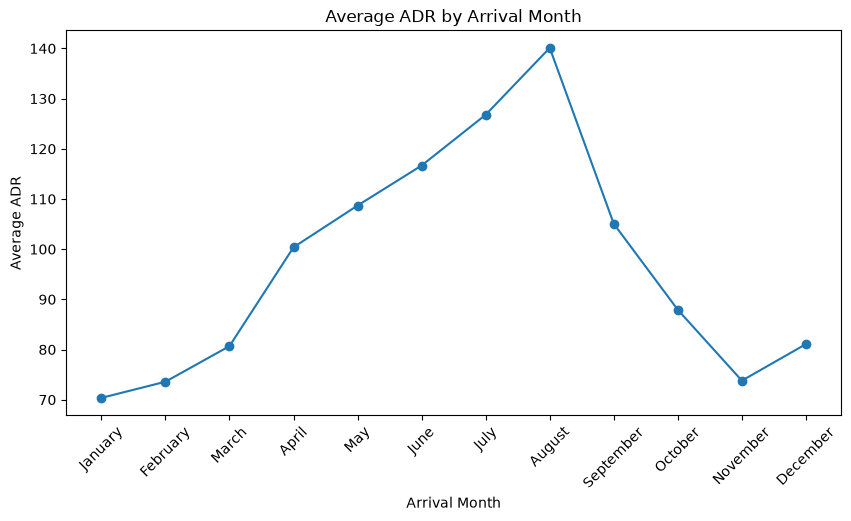

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_adr.index,
    monthly_adr.values,
    marker='o'
)

plt.title('Average ADR by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Average ADR')

plt.xticks(rotation=45)

plt.show()

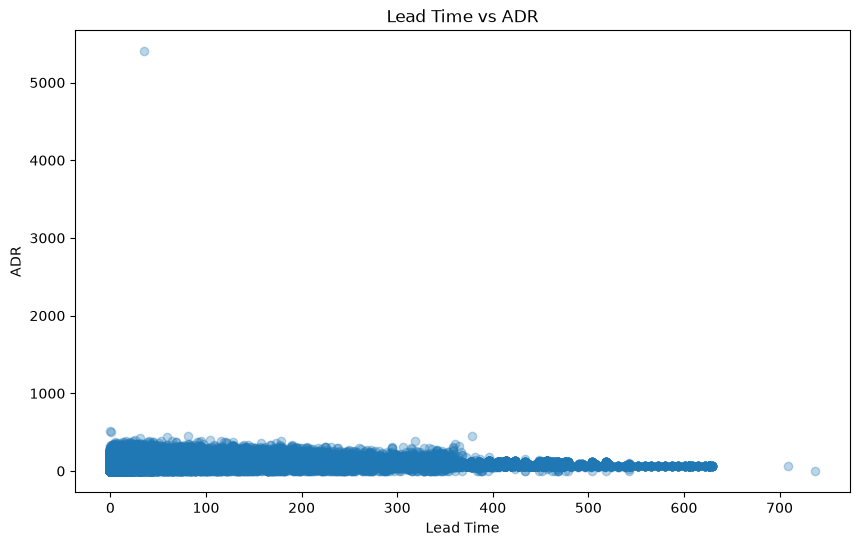

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['lead_time'],
    df['adr'],
    alpha=0.3
)

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.show()

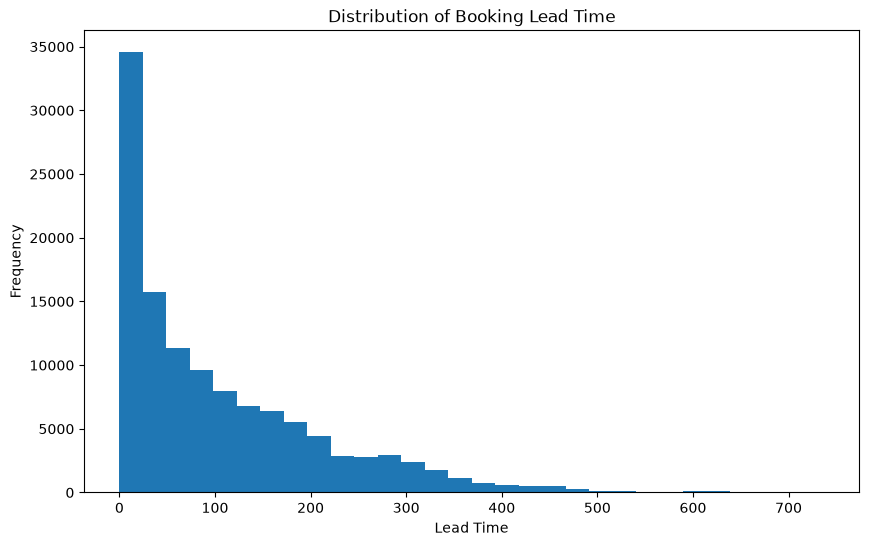

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['lead_time'],
    bins=30
)

plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

plt.show()

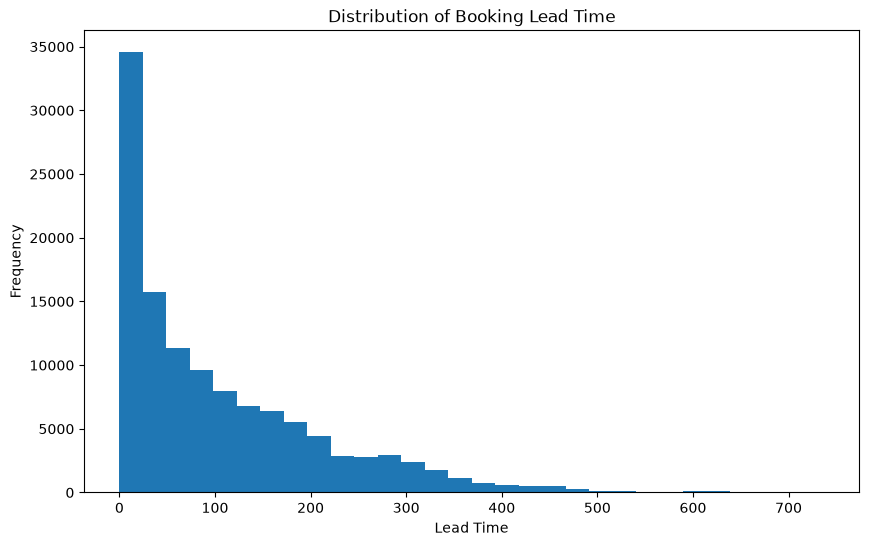

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['lead_time'],
    bins=30
)

plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

plt.show()

In [19]:
hotel_monthly = (
    df.groupby(['arrival_date_month', 'hotel'], observed=False)['adr']
    .mean()
    .unstack('hotel')
    .reindex(months)
)

hotel_monthly


hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,82.628986,49.461883
February,85.088278,55.171930
March,92.643116,57.520147
April,111.251838,77.849496
May,121.638560,78.758134
June,119.074341,110.444749
July,110.734292,155.181299
August,114.680455,186.790574
September,110.004661,93.252030


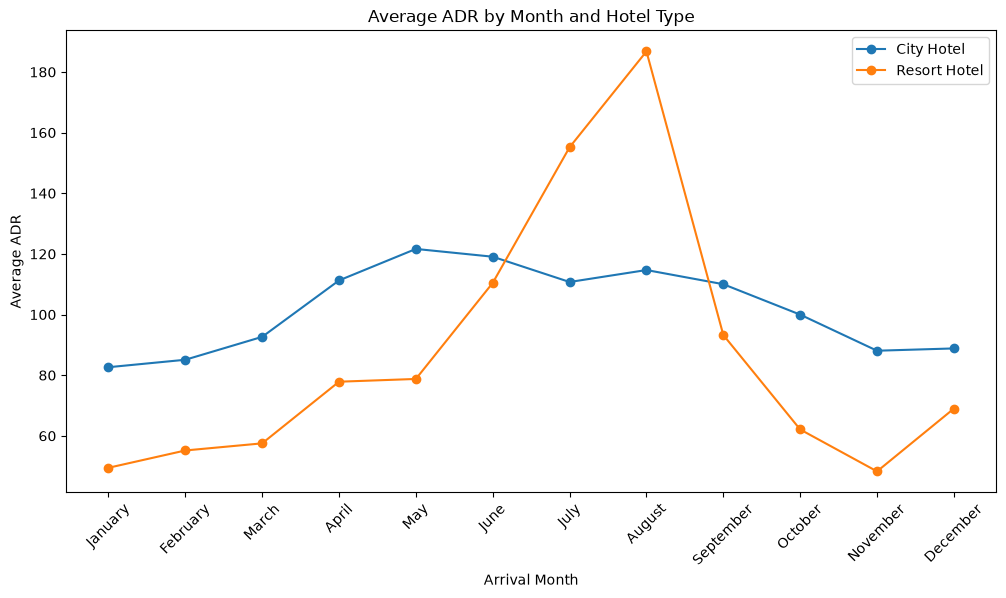

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    hotel_monthly.index,
    hotel_monthly['City Hotel'],
    marker='o',
    label='City Hotel'
)

plt.plot(
    hotel_monthly.index,
    hotel_monthly['Resort Hotel'],
    marker='o',
    label='Resort Hotel'
)

plt.title('Average ADR by Month and Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Average ADR')

plt.xticks(rotation=45)

plt.legend()

plt.show()

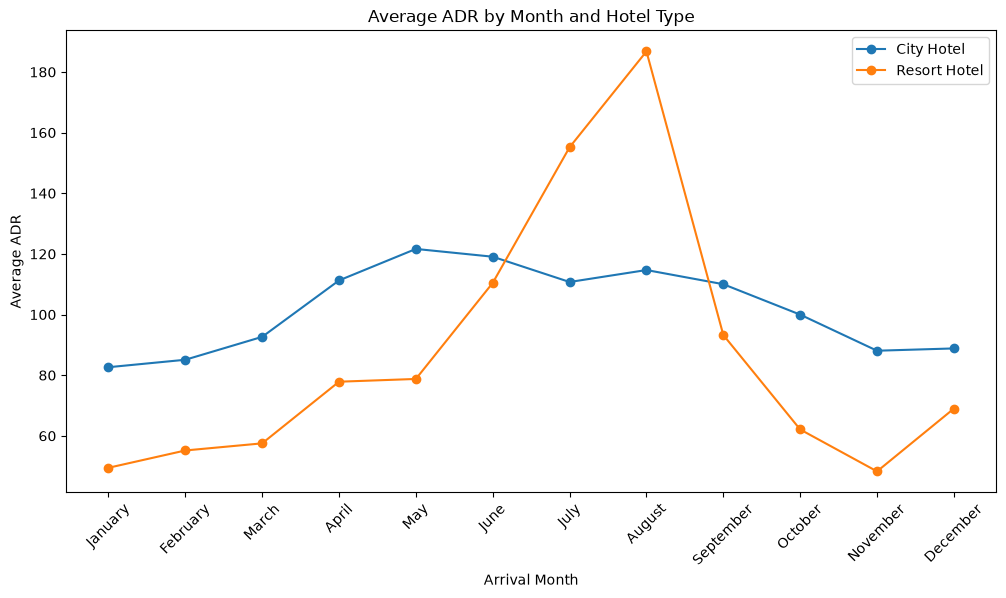

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    hotel_monthly.index,
    hotel_monthly['City Hotel'],
    marker='o',
    label='City Hotel'
)

plt.plot(
    hotel_monthly.index,
    hotel_monthly['Resort Hotel'],
    marker='o',
    label='Resort Hotel'
)

plt.title('Average ADR by Month and Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Average ADR')

plt.xticks(rotation=45)

plt.legend()

plt.show()

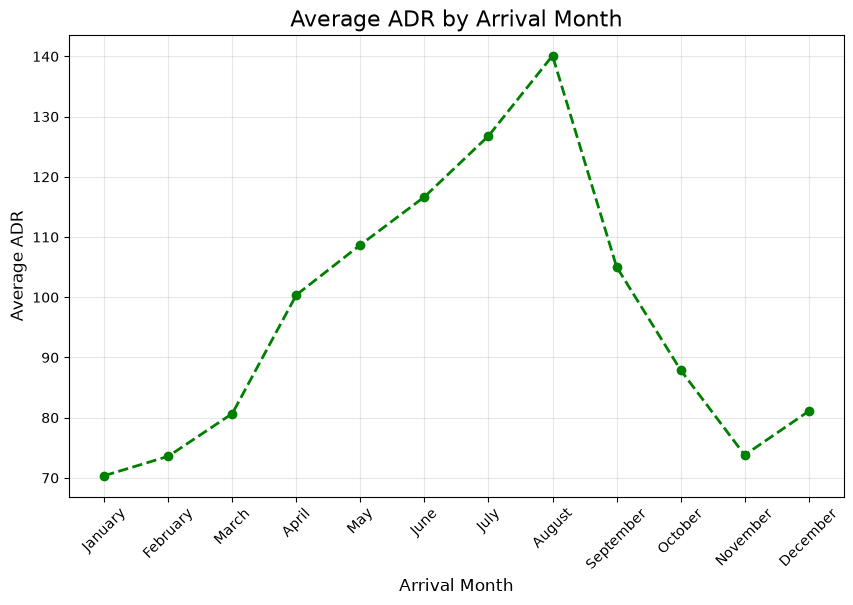

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_adr.index,
    monthly_adr.values,
    marker='o',
    color='green',
    linewidth=2,
    linestyle='--'
)

plt.title(
    'Average ADR by Arrival Month',
    fontsize=16
)

plt.xlabel('Arrival Month', fontsize=12)
plt.ylabel('Average ADR', fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.show()

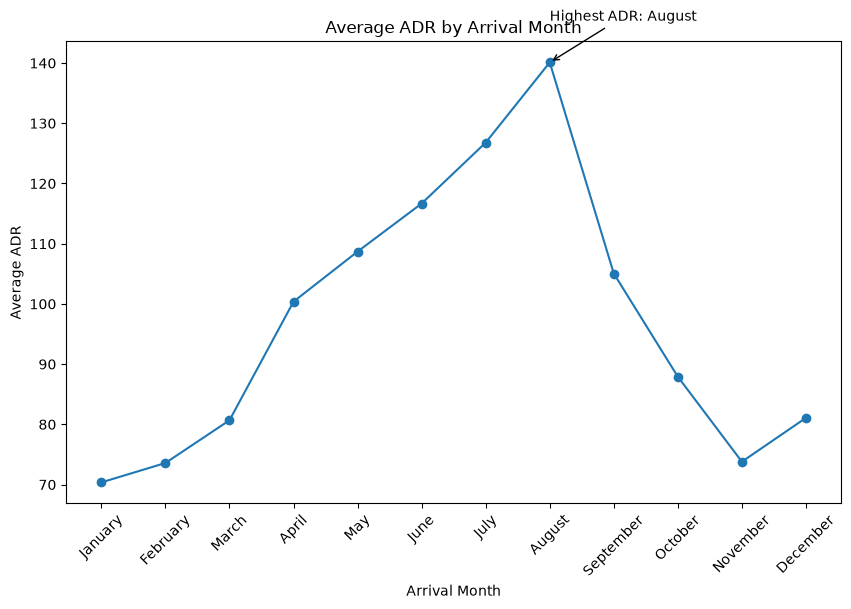

In [23]:
max_month = monthly_adr.idxmax()
max_value = monthly_adr.max()

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_adr.index,
    monthly_adr.values,
    marker='o'
)

plt.annotate(
    f'Highest ADR: {max_month}',
    xy=(max_month, max_value),
    xytext=(0, 30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.title('Average ADR by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Average ADR')

plt.xticks(rotation=45)

plt.show()

In [24]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

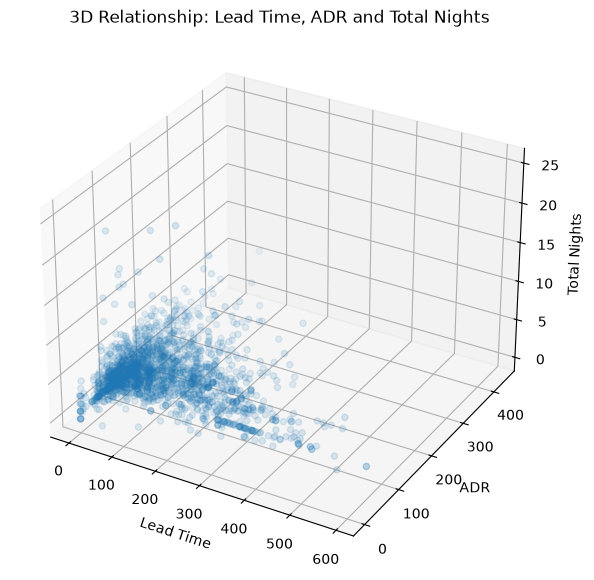

In [25]:
from mpl_toolkits.mplot3d import Axes3D

sample_df = df.sample(2000, random_state=42)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample_df['lead_time'],
    sample_df['adr'],
    sample_df['total_nights'],
    alpha=0.4
)

ax.set_xlabel('Lead Time')
ax.set_ylabel('ADR')
ax.set_zlabel('Total Nights')

ax.set_title('3D Relationship: Lead Time, ADR and Total Nights')

plt.show()

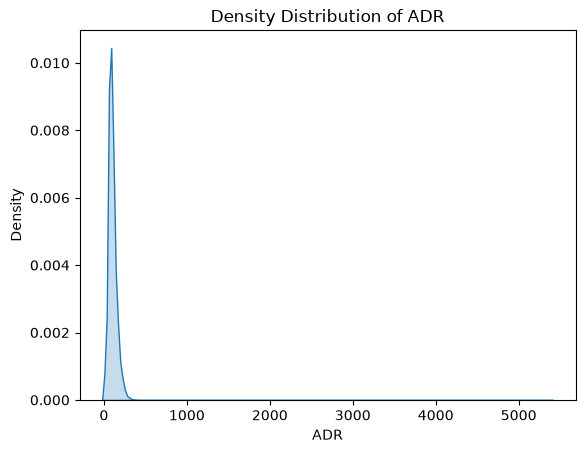

In [26]:
sns.kdeplot(
    data=df,
    x='adr',
    fill=True
)

plt.title('Density Distribution of ADR')
plt.xlabel('ADR')

plt.show()

In [27]:
contour_df = df[
    (df['adr'] > 0) &
    (df['lead_time'] >= 0)
].sample(5000, random_state=42)

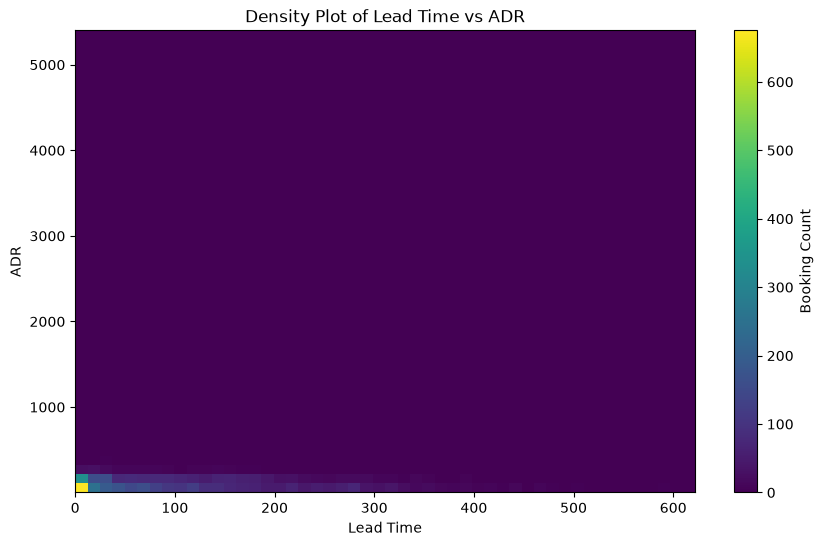

In [28]:
plt.figure(figsize=(10, 6))

plt.hist2d(
    contour_df['lead_time'],
    contour_df['adr'],
    bins=50,
    cmap='viridis'
)

plt.colorbar(label='Booking Count')

plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.title('Density Plot of Lead Time vs ADR')
plt.show()


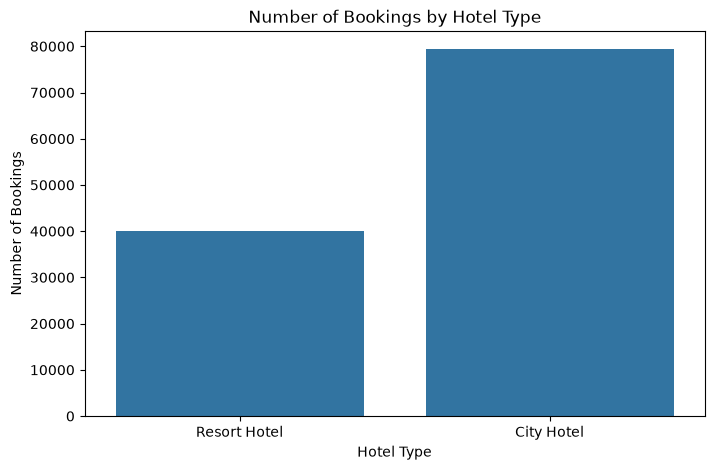

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='hotel'
)

plt.title('Number of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

#Unit -3

In [30]:
mean_lead_time = df['lead_time'].mean()

print("Mean Lead Time:", mean_lead_time)

Mean Lead Time: 104.01141636652986


In [31]:
median_lead_time = df['lead_time'].median()

print("Median Lead Time:", median_lead_time)

Median Lead Time: 69.0


In [32]:
std_lead_time = df['lead_time'].std()

print("Standard Deviation:", std_lead_time)

Standard Deviation: 106.86309704798794


In [33]:
Q1 = df['lead_time'].quantile(0.25)
Q2 = df['lead_time'].quantile(0.50)
Q3 = df['lead_time'].quantile(0.75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

Q1: 18.0
Q2: 69.0
Q3: 160.0


In [34]:
bins = [0, 30, 60, 90, 180, 365, 1000]

labels = [
    '0-30',
    '31-60',
    '61-90',
    '91-180',
    '181-365',
    '366+'
]

lead_time_groups = pd.cut(
    df['lead_time'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

lead_time_groups.value_counts().sort_index()

lead_time
0-30       38706
31-60      16970
61-90      12583
91-180     26439
181-365    21544
366+        3148
Name: count, dtype: int64

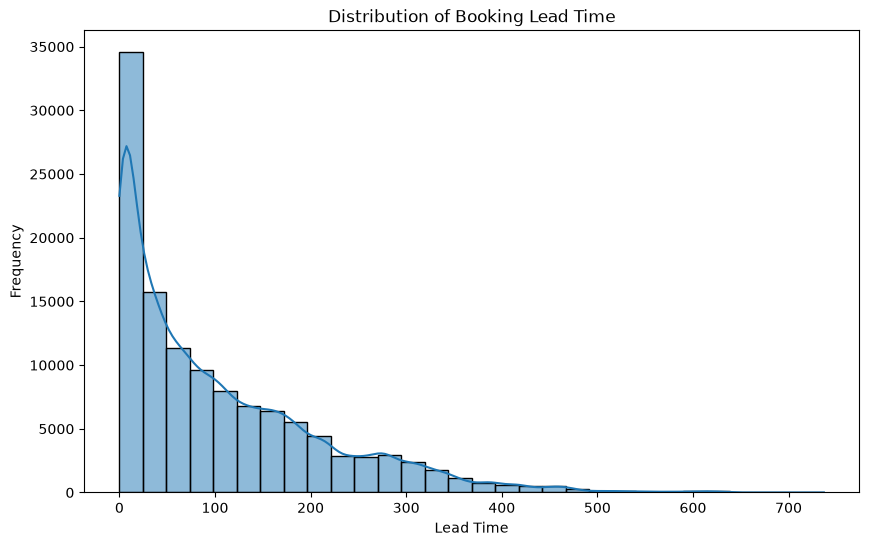

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['lead_time'],
    bins=30,
    kde=True
)

plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

plt.show()

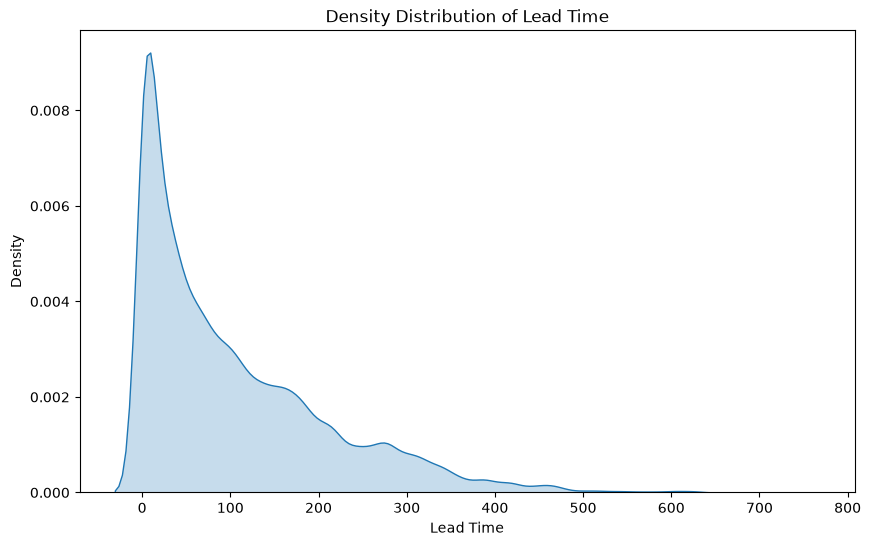

In [36]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='lead_time',
    fill=True
)

plt.title('Density Distribution of Lead Time')
plt.xlabel('Lead Time')

plt.show()

In [37]:
skewness = df['lead_time'].skew()

print("Skewness:", skewness)

Skewness: 1.3465498727254264


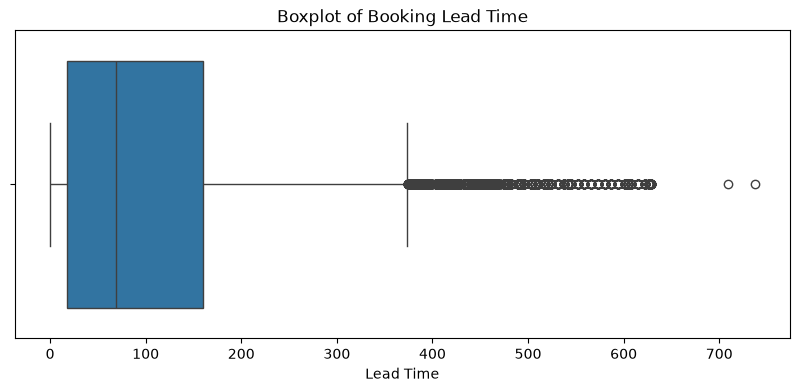

In [38]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['lead_time']
)

plt.title('Boxplot of Booking Lead Time')
plt.xlabel('Lead Time')

plt.show()

In [39]:
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 18.0
Q3: 160.0
IQR: 142.0
Lower Bound: -195.0
Upper Bound: 373.0


In [40]:
outliers = df[
    (df['lead_time'] < lower_bound) |
    (df['lead_time'] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 3005


In [41]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [42]:
print("Mean:", df['adr'].mean())
print("Median:", df['adr'].median())
print("Standard Deviation:", df['adr'].std())
print("Skewness:", df['adr'].skew())

Mean: 101.83112153446687
Median: 94.575
Standard Deviation: 50.53579028554871
Skewness: 10.53021398218952


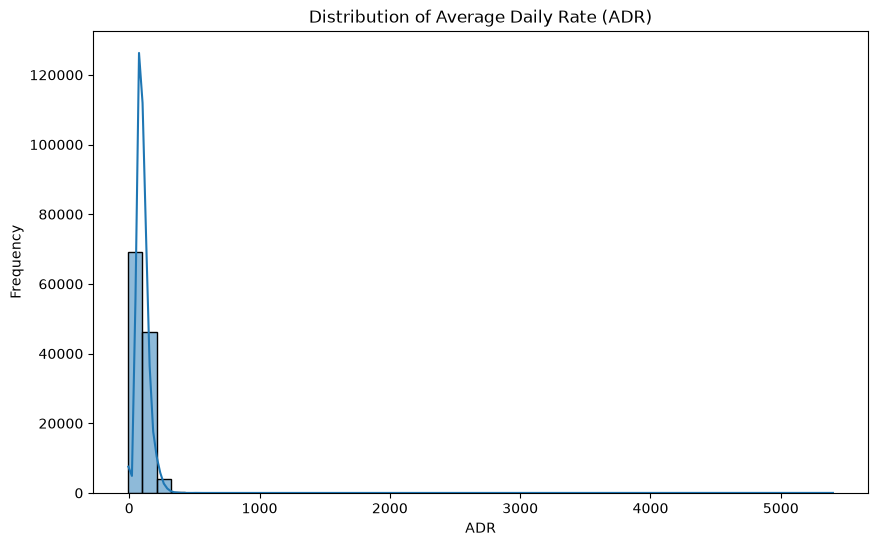

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['adr'],
    bins=50,
    kde=True
)

plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequency')

plt.show()

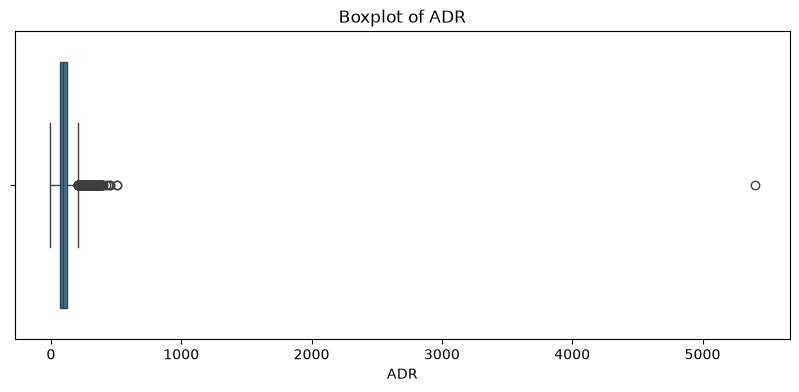

In [44]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['adr']
)

plt.title('Boxplot of ADR')
plt.xlabel('ADR')

plt.show()

In [45]:
hotel_frequency = df['hotel'].value_counts()

print(hotel_frequency)

hotel_percentage = (
    df['hotel']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(hotel_percentage)

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
hotel
City Hotel      66.45
Resort Hotel    33.55
Name: proportion, dtype: float64


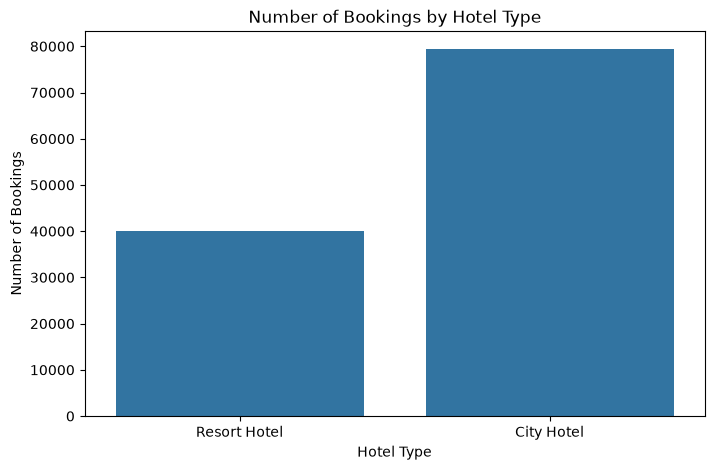

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='hotel'
)

plt.title('Number of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

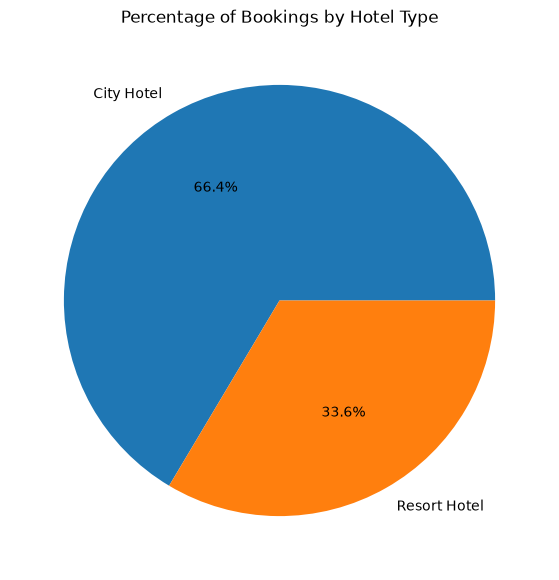

In [47]:
hotel_frequency.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title('Percentage of Bookings by Hotel Type')
plt.ylabel('')

plt.show()

In [48]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [49]:
df['customer_type'].value_counts(
    normalize=True
).mul(100).round(2)

customer_type
Transient          75.06
Transient-Party    21.04
Contract            3.41
Group               0.48
Name: proportion, dtype: float64

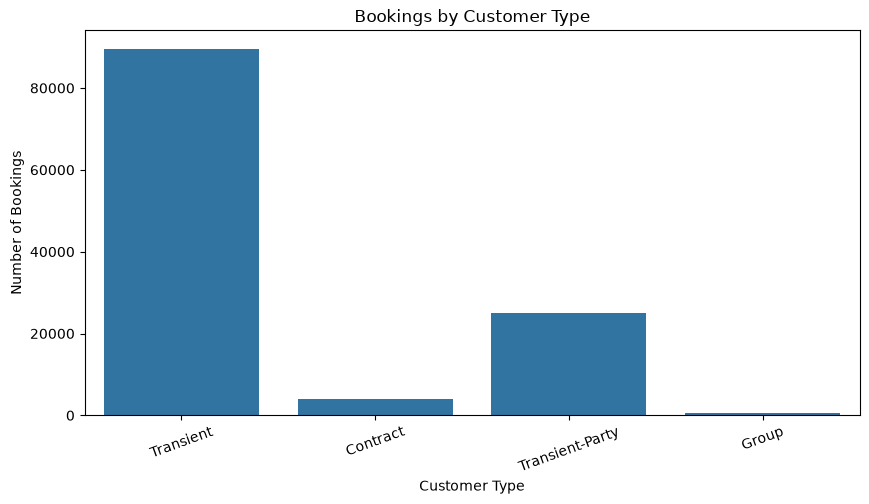

In [50]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='customer_type'
)

plt.title('Bookings by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=20)

plt.show()

In [51]:
market_frequency = df['market_segment'].value_counts()

print(market_frequency)

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


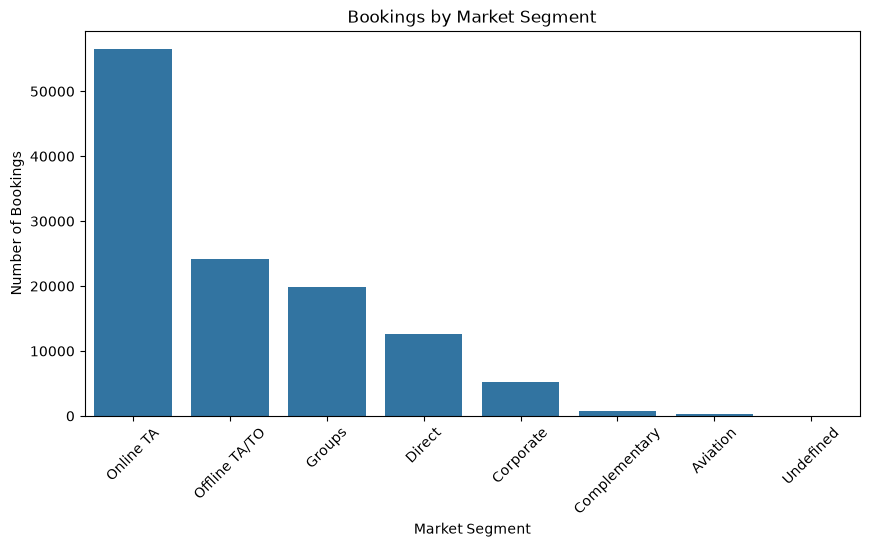

In [52]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.show()

In [53]:
order=df['market_segment'].value_counts().index

## Unit 3 – Summary

The univariate analysis examined individual numerical and categorical
variables in the hotel booking dataset.

Numerical variables such as lead_time and adr were analyzed using
mean, median, standard deviation, quartiles, histograms, density plots,
boxplots, skewness, and outlier detection.

Categorical variables such as hotel, customer_type, and market_segment
were analyzed using frequency tables, bar charts, and pie charts.

The analysis provides an understanding of the individual distributions
and characteristics of the variables before studying relationships
between multiple variables.

## Unit 4 – Bivariate Analysis

Bivariate analysis was performed to study the relationships between pairs of variables in the hotel booking dataset. Numerical variables were analyzed using scatter plots, Pearson correlation, Spearman correlation, and trend lines. Categorical variables were compared using crosstabulation, grouped bar charts, and stacked bar charts. Numerical and categorical variables were analyzed using boxplots and violin plots. These analyses helped identify relationships between booking characteristics, hotel type, pricing, customer type, market segment, and cancellation behavior.


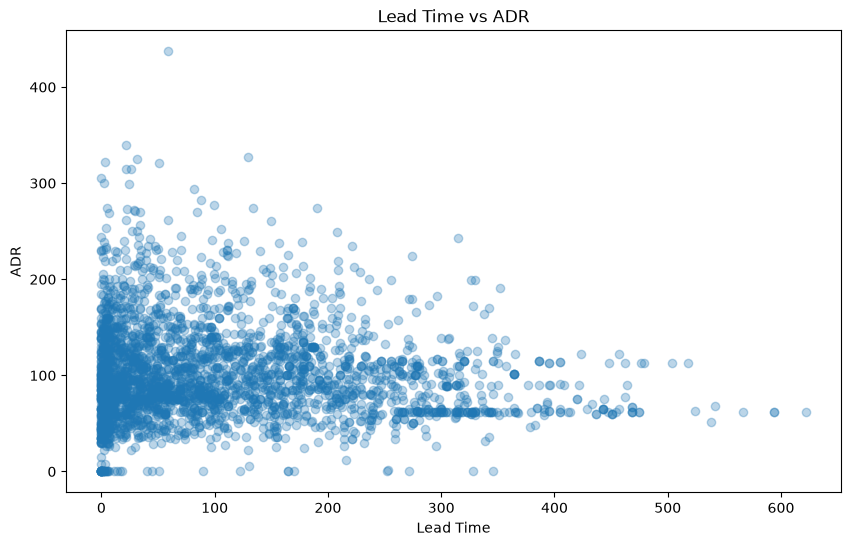

In [54]:
import matplotlib.pyplot as plt

sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df['lead_time'],
    sample_df['adr'],
    alpha=0.3
)

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.show()

In [55]:
pearson_corr = df[['lead_time', 'adr']].corr(method='pearson')

pearson_corr

,lead_time,adr
lead_time,1.000000,-0.063077
adr,-0.063077,1.000000


In [56]:
spearman_corr = df[['lead_time', 'adr']].corr(method='spearman')

spearman_corr

,lead_time,adr
lead_time,1.000000,0.015034
adr,0.015034,1.000000


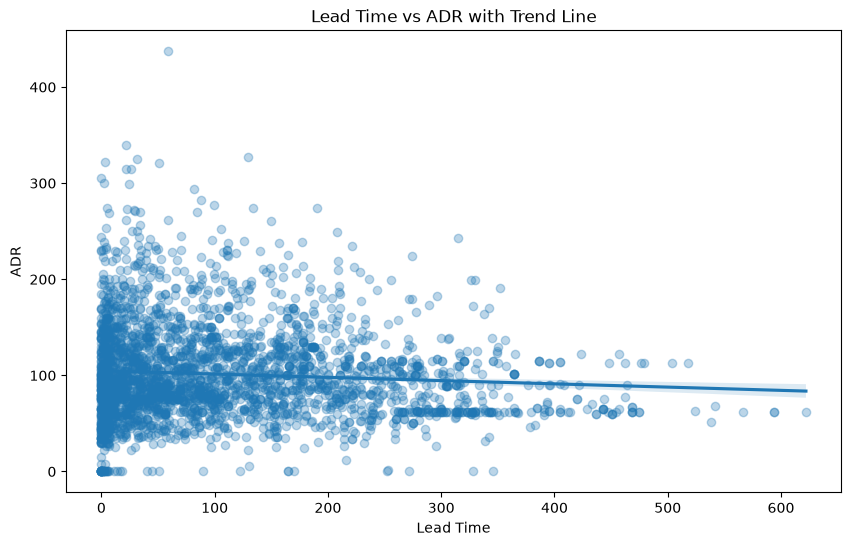

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=sample_df,
    x='lead_time',
    y='adr',
    scatter_kws={'alpha': 0.3}
)

plt.title('Lead Time vs ADR with Trend Line')
plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.show()

In [58]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

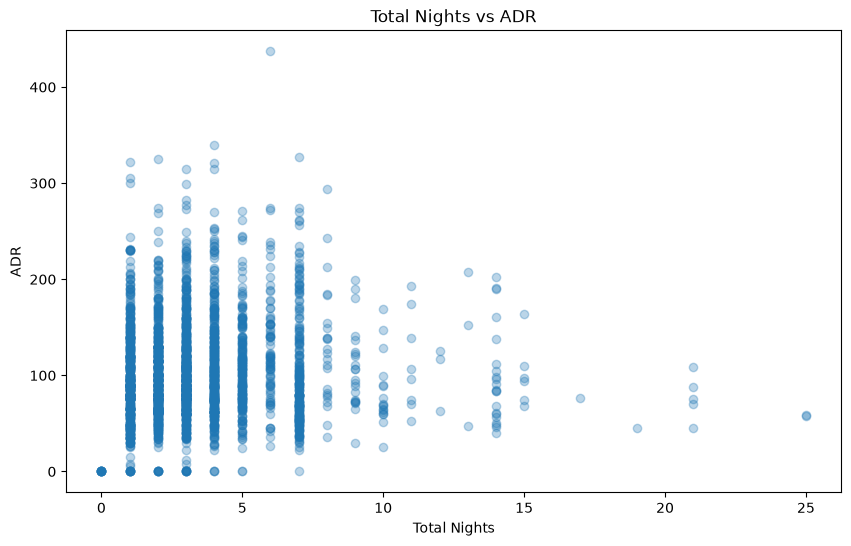

In [59]:
sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df['total_nights'],
    sample_df['adr'],
    alpha=0.3
)

plt.title('Total Nights vs ADR')
plt.xlabel('Total Nights')
plt.ylabel('ADR')

plt.show()

In [60]:
df[['total_nights', 'adr']].corr()

,total_nights,adr
total_nights,1.000000,0.067945
adr,0.067945,1.000000


In [61]:
crosstab = pd.crosstab(
    df['hotel'],
    df['is_canceled']
)

crosstab

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


In [62]:
cancellation_percentage = pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

cancellation_percentage.round(2)

is_canceled,0,1
hotel,,
City Hotel,58.27,41.73
Resort Hotel,72.24,27.76


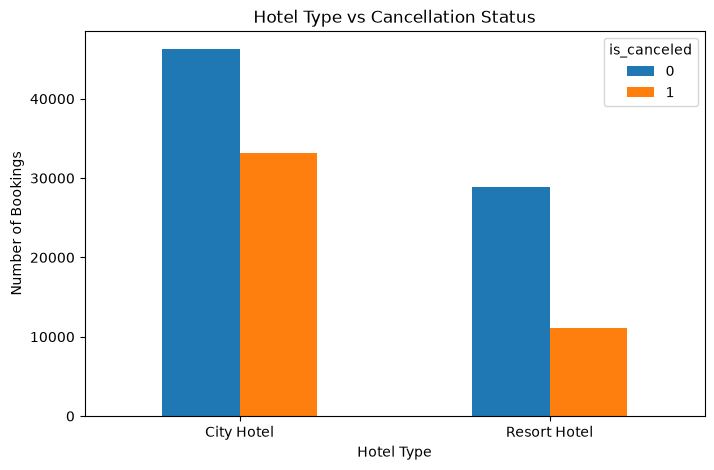

In [63]:
crosstab.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Hotel Type vs Cancellation Status')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)

plt.show()

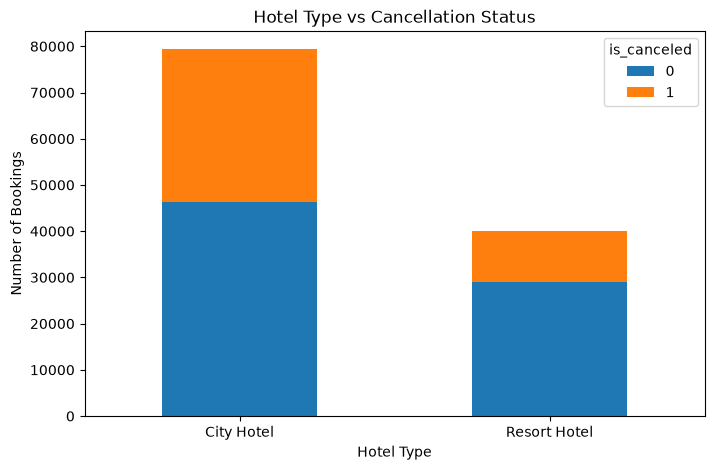

In [64]:
crosstab.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Hotel Type vs Cancellation Status')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)

plt.show()

In [65]:
customer_cancellation = pd.crosstab(
    df['customer_type'],
    df['is_canceled']
)

customer_cancellation

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


In [66]:
customer_cancellation_percentage = pd.crosstab(
    df['customer_type'],
    df['is_canceled'],
    normalize='index'
) * 100

customer_cancellation_percentage.round(2)

is_canceled,0,1
customer_type,,
Contract,69.04,30.96
Group,89.77,10.23
Transient,59.25,40.75
Transient-Party,74.57,25.43


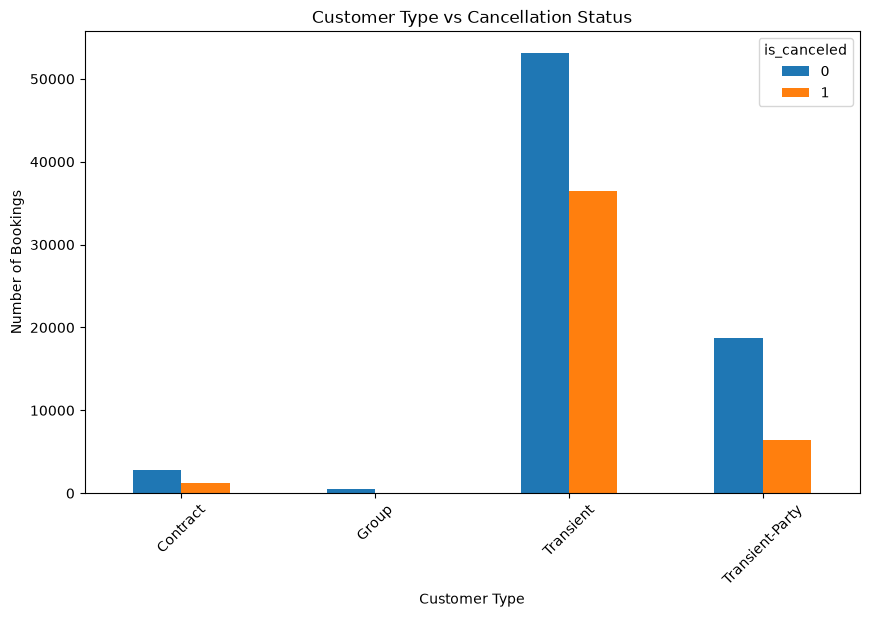

In [67]:
customer_cancellation.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Customer Type vs Cancellation Status')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.show()

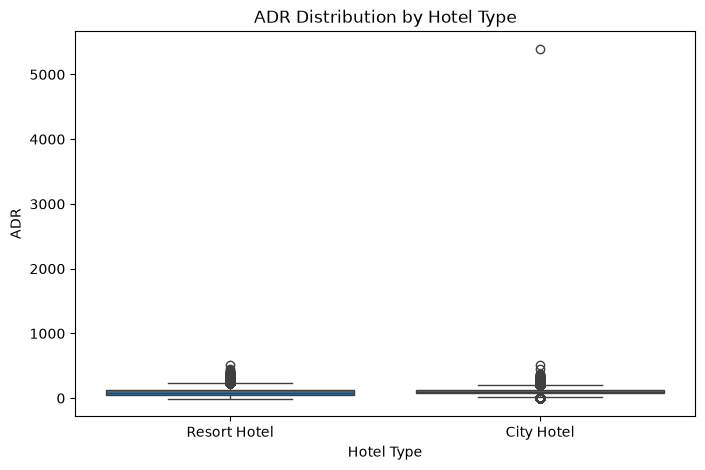

In [68]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='hotel',
    y='adr'
)

plt.title('ADR Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')

plt.show()

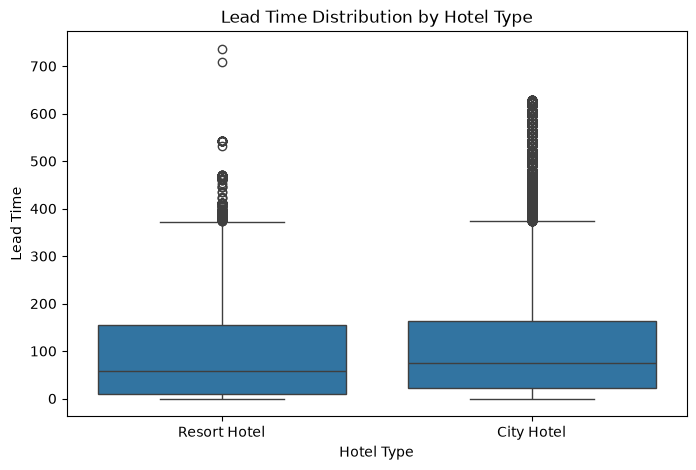

In [69]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='hotel',
    y='lead_time'
)

plt.title('Lead Time Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Lead Time')

plt.show()

In [70]:
cancellation_by_segment = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .sort_values(ascending=False)
)

cancellation_by_segment

market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64

In [71]:
(cancellation_by_segment * 100).round(2)

market_segment
Undefined        100.00
Groups            61.06
Online TA         36.72
Offline TA/TO     34.32
Aviation          21.94
Corporate         18.73
Direct            15.34
Complementary     13.06
Name: is_canceled, dtype: float64

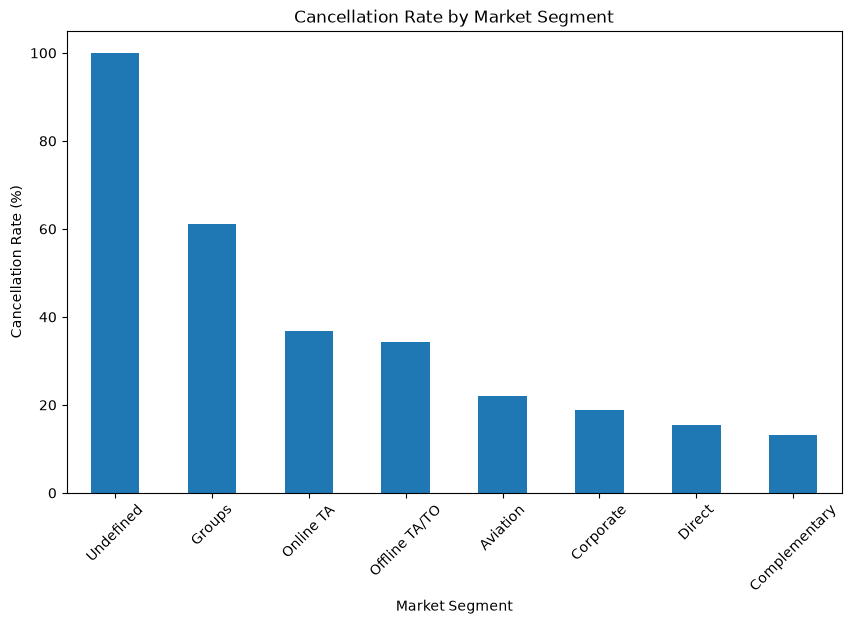

In [72]:
plt.figure(figsize=(10, 6))

cancellation_by_segment.mul(100).plot(
    kind='bar'
)

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=45)

plt.show()

## unit 5

In [73]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

In [74]:
numeric_cols = [
    'lead_time',
    'adr',
    'total_nights',
    'adults',
    'children',
    'babies',
    'is_canceled'
]

numeric_df = df[numeric_cols]

numeric_df.head()

,lead_time,adr,total_nights,adults,children,babies,is_canceled
0,342,0.0,0,2,0.0,0,0
1,737,0.0,0,2,0.0,0,0
2,7,75.0,1,1,0.0,0,0
3,13,75.0,1,1,0.0,0,0
4,14,98.0,2,2,0.0,0,0


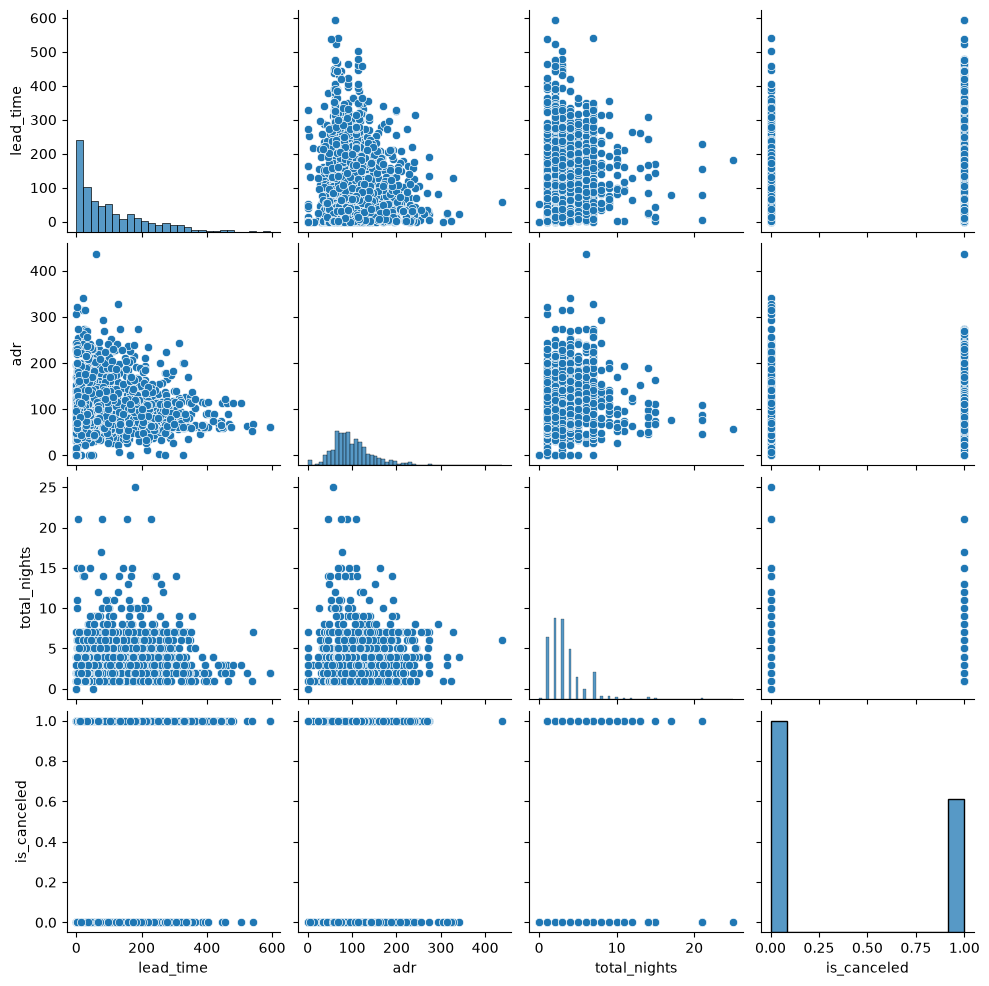

In [75]:
sns.pairplot(
    df[
        ['lead_time',
         'adr',
         'total_nights',
         'is_canceled']
    ].sample(2000, random_state=42)
)

plt.show()

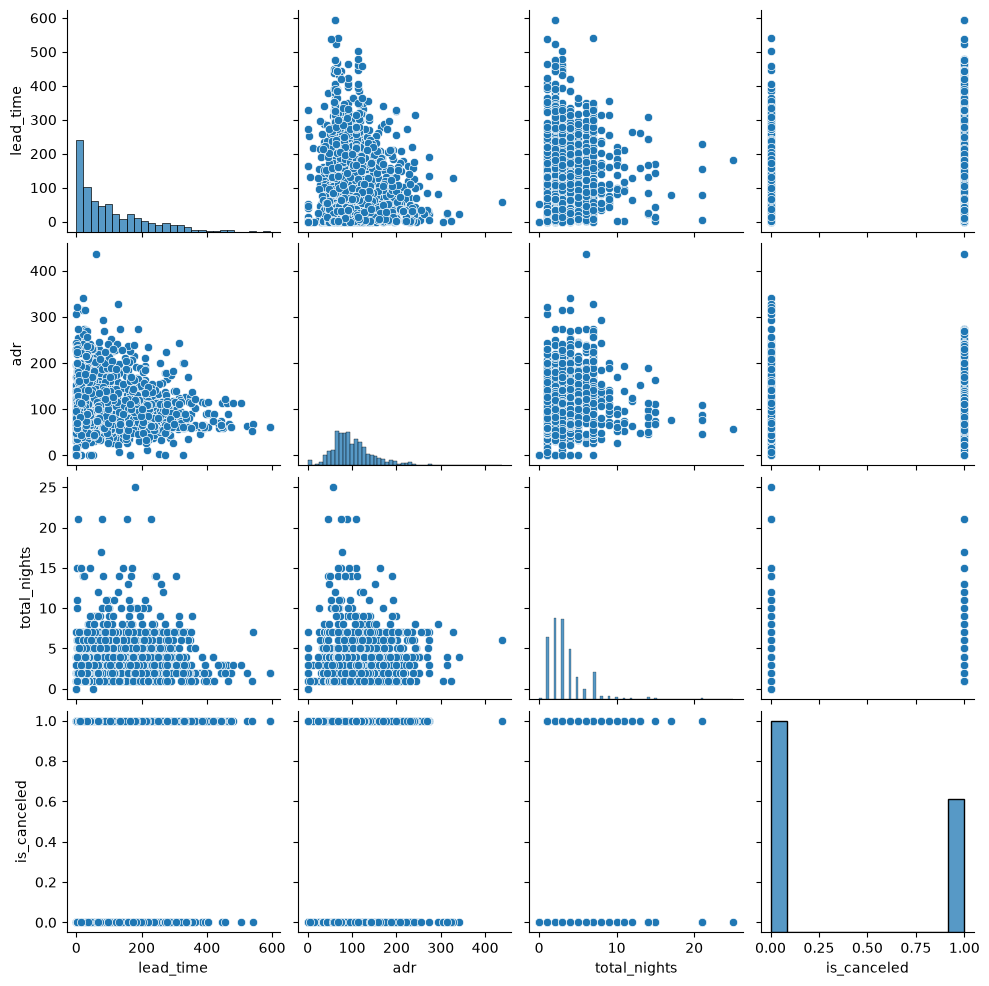

In [76]:
sns.pairplot(
    df[
        ['lead_time',
         'adr',
         'total_nights',
         'is_canceled']
    ].sample(2000, random_state=42)
)

plt.show()

In [77]:
corr_matrix = df[
    ['lead_time',
     'adr',
     'total_nights',
     'adults',
     'children',
     'babies',
     'is_canceled']
].corr()

corr_matrix

,lead_time,adr,total_nights,adults,children,babies,is_canceled
lead_time,1.000000,-0.063077,0.157167,0.119519,-0.037622,-0.020915,0.293123
adr,-0.063077,1.000000,0.067945,0.230641,0.324854,0.029186,0.047557
total_nights,0.157167,0.067945,1.000000,0.105249,0.050864,0.022283,0.017779
adults,0.119519,0.230641,0.105249,1.000000,0.030447,0.018146,0.060017
children,-0.037622,0.324854,0.050864,0.030447,1.000000,0.024030,0.005048
babies,-0.020915,0.029186,0.022283,0.018146,0.024030,1.000000,-0.032491
is_canceled,0.293123,0.047557,0.017779,0.060017,0.005048,-0.032491,1.000000


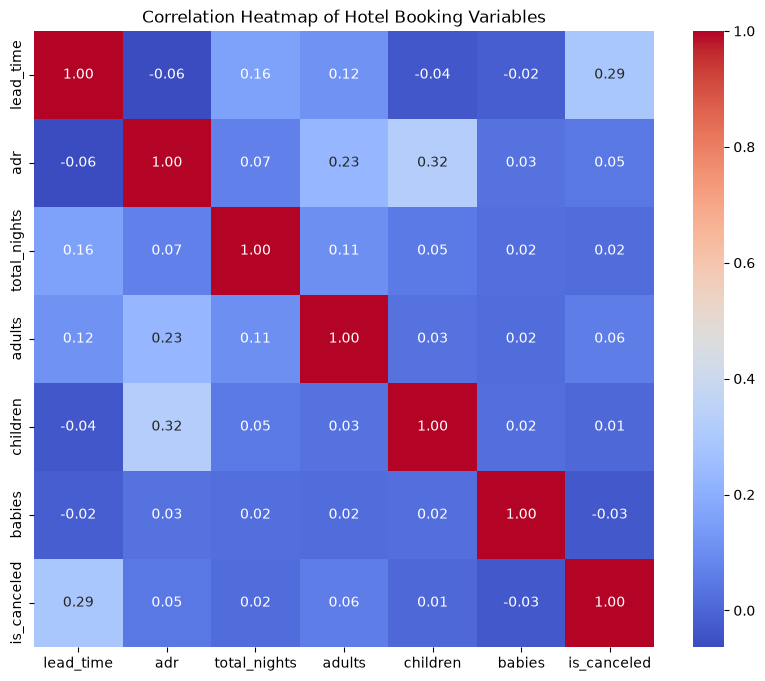

In [78]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Hotel Booking Variables')

plt.show()

In [79]:
corr_matrix.abs().unstack().sort_values(
    ascending=False
)

lead_time     lead_time       1.000000
adr           adr             1.000000
total_nights  total_nights    1.000000
children      children        1.000000
adults        adults          1.000000
babies        babies          1.000000
is_canceled   is_canceled     1.000000
adr           children        0.324854
children      adr             0.324854
is_canceled   lead_time       0.293123
lead_time     is_canceled     0.293123
adr           adults          0.230641
adults        adr             0.230641
lead_time     total_nights    0.157167
total_nights  lead_time       0.157167
adults        lead_time       0.119519
lead_time     adults          0.119519
adults        total_nights    0.105249
total_nights  adults          0.105249
adr           total_nights    0.067945
total_nights  adr             0.067945
adr           lead_time       0.063077
lead_time     adr             0.063077
is_canceled   adults          0.060017
adults        is_canceled     0.060017
total_nights  children   

In [99]:
import numpy as np

corr_without_diagonal = corr_matrix.mask(
    np.eye(len(corr_matrix), dtype=bool)
)

corr_without_diagonal.abs().unstack().sort_values(
    ascending=False
).head(10)

adr           children        0.324854
children      adr             0.324854
is_canceled   lead_time       0.293123
lead_time     is_canceled     0.293123
adr           adults          0.230641
adults        adr             0.230641
total_nights  lead_time       0.157167
lead_time     total_nights    0.157167
              adults          0.119519
adults        lead_time       0.119519
dtype: float64

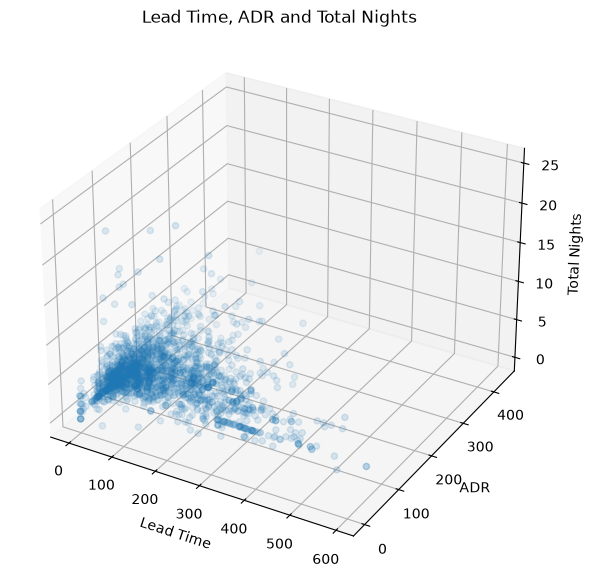

In [83]:
from mpl_toolkits.mplot3d import Axes3D

sample_df = df.sample(2000, random_state=42)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    sample_df['lead_time'],
    sample_df['adr'],
    sample_df['total_nights'],
    alpha=0.4
)

ax.set_xlabel('Lead Time')
ax.set_ylabel('ADR')
ax.set_zlabel('Total Nights')

ax.set_title(
    'Lead Time, ADR and Total Nights'
)

plt.show()

In [84]:
from sklearn.preprocessing import StandardScaler

pca_data = df[
    ['lead_time',
     'adr',
     'total_nights',
     'adults',
     'children',
     'babies']
].copy()

In [85]:
pca_data.isnull().sum()

lead_time       0
adr             0
total_nights    0
adults          0
children        4
babies          0
dtype: int64

In [86]:
pca_data = pca_data.fillna(
    pca_data.median()
)

In [87]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    pca_data
)

In [88]:
from sklearn.decomposition import PCA

In [89]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    scaled_data
)

In [90]:
pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,-1.534762,1.536168
1,-1.220654,4.075756
2,-1.518313,-1.327125
3,-1.513542,-1.288549
4,-0.315982,-0.664778


In [91]:
pca.explained_variance_ratio_

array([0.24236993, 0.20186056])

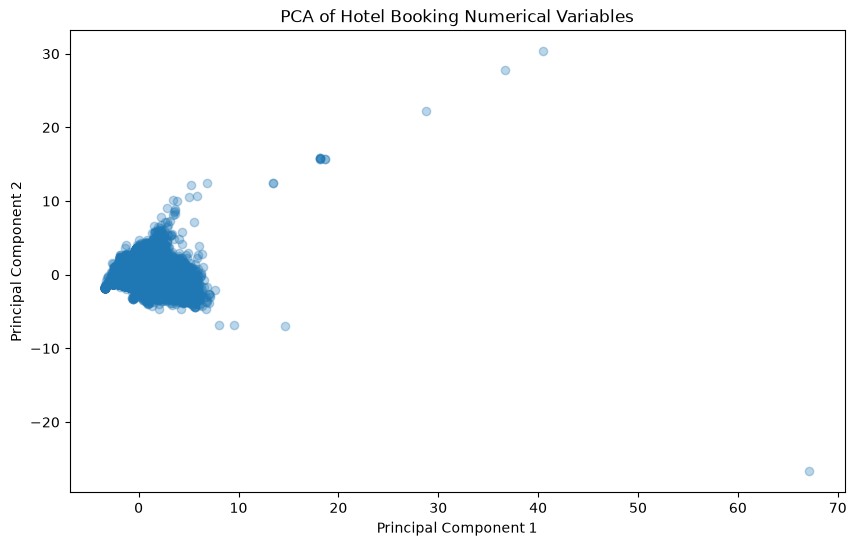

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.3
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title(
    'PCA of Hotel Booking Numerical Variables'
)

plt.show()

In [93]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_data.columns
)

loadings

,PC1,PC2
lead_time,0.084978,0.687056
adr,0.644080,-0.247692
total_nights,0.294859,0.496407
adults,0.456648,0.310464
children,0.522400,-0.346227
babies,0.097817,-0.062623


In [94]:
from sklearn.manifold import TSNE

In [95]:
tsne_sample = pca_data.sample(
    2000,
    random_state=42
)

In [96]:
tsne_sample = pca_data.sample(
    2000,
    random_state=42
)

In [100]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_result = tsne.fit_transform(
    tsne_sample
)

In [101]:
tsne_df = pd.DataFrame(
    tsne_result,
    columns=['TSNE1', 'TSNE2']
)

tsne_df.head()

,TSNE1,TSNE2
0,40.565071,-7.076516
1,-2.557177,-14.633389
2,-31.824194,-22.422049
3,-44.393368,5.430023
4,-5.984710,1.015672


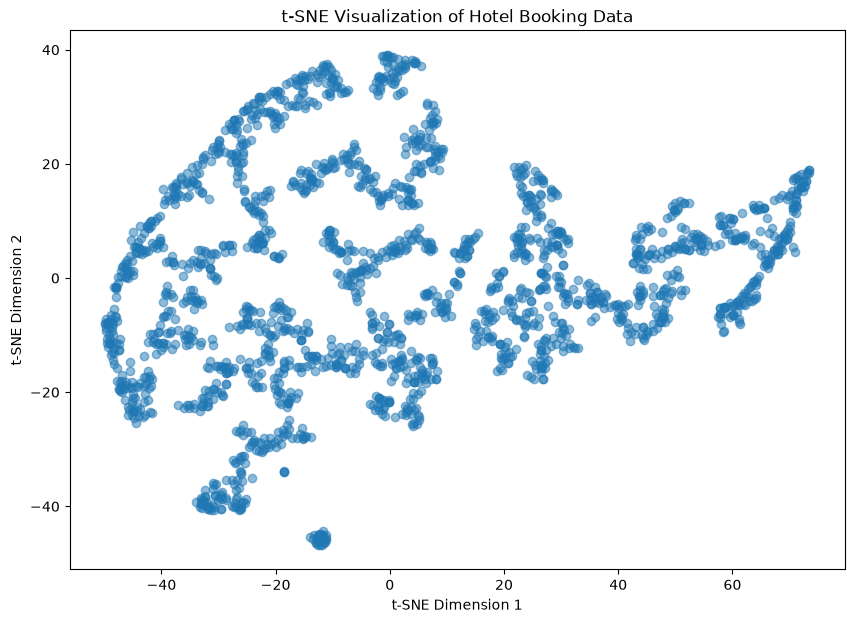

In [102]:
plt.figure(figsize=(10, 7))

plt.scatter(
    tsne_df['TSNE1'],
    tsne_df['TSNE2'],
    alpha=0.5
)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.title(
    't-SNE Visualization of Hotel Booking Data'
)

plt.show()

## Unit 5 – Multivariate Analysis

Multivariate analysis was used to study several variables simultaneously in the hotel booking dataset. Pair plots and 3D visualizations were used to examine relationships among multiple numerical variables. A correlation matrix and heatmap were used to identify the strength and direction of relationships between numerical variables. Principal Component Analysis (PCA) was applied after standardization to reduce the dimensionality of the numerical dataset and examine the variance explained by the principal components. t-SNE was also applied to a sample of the data to visualize high-dimensional observations in a two-dimensional space and explore possible patterns or clusters.
